# Take-Profit Strategy Research

This notebook compares exit strategies for trades entered via the signal pipeline.

## Strategies Compared

| Strategy | Logic | Default |
|----------|-------|---------|
| `fixed_pct` | Exit when close >= entry * (1 + tp%) | tp=10% |
| `trailing_stop` | Exit when close drops trail% from peak | trail=5% |
| `rsi_exit` | Exit when RSI crosses above threshold then drops back below | threshold=70 |
| `resistance_exit` | Exit when close reaches RESISTANCE_LEVEL | Uses column |
| `kill_candle_exit` | Exit on kill candle detection | existing params |
| `time_based` | Exit after N trading days | hold_days=20 |

All strategies share: stop-loss=5%, max_hold_days=60

In [1]:
# Setup and Imports
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Import project modules
from modules.data import DataLoader
from modules.features import TechnicalIndicators, HighPointIndicators, FeaturePipeline
from modules.evaluation import TakeProfitBacktester

print("Modules loaded successfully!")

Modules loaded successfully!


## 1. Load Data & Calculate Features

In [2]:
# Initialize data loader — load full IS period for RSIReversalStrategy calibration
from modules.config.capstone_v4_params import IS_START, IS_END
from modules.features import TechnicalIndicators, FeaturePipeline

cache_dir = os.path.join(project_root, 'cache', 'constituent_data')
loader = DataLoader(cache_dir=cache_dir, auto_update=False)

sp500_tickers = loader.get_sp500_tickers()
print(f"Total S&P 500 tickers: {len(sp500_tickers)}")
print(f"Loading IS period: {IS_START} to {IS_END}")

pipeline = FeaturePipeline([TechnicalIndicators()])

print("Loading and computing technical indicators ...")
stock_data_raw = {}
for ticker in sp500_tickers:
    try:
        df = loader.load_ticker(ticker)
        if df is None or df.empty:
            continue
        df = pipeline.transform(df)
        stock_data_raw[ticker] = df
    except Exception:
        pass

print(f"Loaded {len(stock_data_raw)} tickers with features.")


Total S&P 500 tickers: 510
Loading IS period: 2015-01-01 to 2025-06-30
Loading and computing technical indicators ...


⚠️  ARE: OHLC data quality issues detected (3 rows affected)
⚠️  AVB: OHLC data quality issues detected (3 rows affected)
⚠️  BEN: OHLC data quality issues detected (5 rows affected)


⚠ Data validation failed for CCL:
  - Volume has 1152 outliers (12.3%)
⚠ Data validation failed for CRH:
  - Volume has 570 outliers (10.7%)


⚠ Data validation failed for CVNA:
  - Volume has 120 outliers (5.3%)
⚠️  DE: OHLC data quality issues detected (4 rows affected)


⚠️  FITB: OHLC data quality issues detected (4 rows affected)
⚠ Data validation failed for GS:
  - Volume has 355 outliers (5.2%)
⚠ Data validation failed for HIG:
  - Volume has 460 outliers (6.0%)


...

⚠️  LII: OHLC data quality issues detected (5 rows affected)
⚠ Data validation failed for LVS:
  - Volume has 554 outliers (10.4%)
⚠ Data validation failed for MA:
  - Volume has 393 outliers (7.8%)
⚠ Data validation failed for MNST:
  - Large date gaps detected (>10 trading days)
  - Volume has 548 outliers (5.6%)


⚠️  NUE: OHLC data quality issues detected (1 rows affected)
⚠️  PCG: OHLC data quality issues detected (6 rows affected)
⚠ Data validation failed for PCG:
  - Volume has 1105 outliers (9.5%)


⚠ Data validation failed for Q:
  - Volume has 18 outliers (14.4%)


⚠ Data validation failed for TKO:
  - Volume has 461 outliers (7.2%)
⚠️  USB: OHLC data quality issues detected (6 rows affected)


⚠ Data validation failed for WEC:
  - Volume has 579 outliers (5.5%)
⚠ Data validation failed for WMT:
  - Large date gaps detected (>10 trading days)
⚠ Data validation failed for ZBRA:
  - Large date gaps detected (>10 trading days)
Loaded 495 tickers with features.


In [3]:
# Add HighPointIndicators on top (needed by HEIGHT_SCORE analysis in Section 6)
from modules.features import HighPointIndicators

hi_pipeline = FeaturePipeline([HighPointIndicators()])
stock_data = {}
skipped = 0
for ticker, df in stock_data_raw.items():
    if len(df) < 60:
        skipped += 1
        continue
    try:
        enriched = hi_pipeline.transform(df.copy())
        stock_data[ticker] = enriched
    except Exception:
        stock_data[ticker] = df  # fallback without HighPoint features

print(f"Enriched {len(stock_data)} tickers with HighPointIndicators (skipped {skipped})")


Enriched 495 tickers with HighPointIndicators (skipped 0)


## 2. Generate Trades (RSIReversalStrategy Signals)

In [4]:
# Generate RSIReversalStrategy signals for IS period (2015-2025)
import sys, os, math
sys.path.insert(0, os.path.abspath('..'))

from modules.config.capstone_v4_params import RSI_THRESHOLD, MIN_CONSECUTIVE, IS_START, IS_END
from modules.data.expiry_calculator import ExpiryCalculator

CACHE_DIR = '../cache'

expiry_dates = ExpiryCalculator.generate_expiry_dates(IS_START, IS_END)

print(f"Scanning RSIReversalStrategy signals over {len(expiry_dates)} expiry dates ...")
signal_records = []

for expiry_date in expiry_dates:
    norm_exp = pd.Timestamp(expiry_date).tz_localize(None)

    for ticker, df in stock_data_raw.items():
        try:
            df_idx = pd.to_datetime(df.index).tz_localize(None)
            candidates = df_idx[df_idx <= norm_exp]
            if len(candidates) < 2:
                continue
            exp_loc = len(candidates) - 1
            sig_loc = exp_loc - 1

            rsi_val = df.iloc[sig_loc].get('RSI', float('nan'))
            cc_val  = df.iloc[sig_loc].get('Consecutive_Count', float('nan'))
            cc_dir  = df.iloc[sig_loc].get('Consecutive_Direction', float('nan'))

            if math.isnan(rsi_val) or math.isnan(cc_val) or math.isnan(cc_dir):
                continue
            if not (rsi_val < RSI_THRESHOLD and cc_val >= MIN_CONSECUTIVE and cc_dir == -1):
                continue

            entry_open = df.iloc[exp_loc].get('Open', float('nan'))
            if math.isnan(entry_open) or entry_open <= 0:
                continue

            signal_records.append({
                'Ticker':            ticker,
                'Date':              norm_exp,
                'Close':             entry_open,
                'RSI':               rsi_val,
                'Consecutive_Count': cc_val,
                'signal_date':       df_idx[sig_loc],
            })
        except Exception:
            continue

signals_df = pd.DataFrame(signal_records)
print(f"Total RSI reversal signals found: {len(signals_df)}")
if not signals_df.empty:
    print(f"Unique tickers: {signals_df['Ticker'].nunique()}")
    print(f"Date range: {signals_df['Date'].min().date()} → {signals_df['Date'].max().date()}")
    display(signals_df.head(5))


Scanning RSIReversalStrategy signals over 126 expiry dates ...


Total RSI reversal signals found: 807
Unique tickers: 398
Date range: 2015-01-16 → 2025-06-20


,Ticker,Date,Close,RSI,Consecutive_Count,signal_date
0,ADI,2015-01-16,44.1327,21.759814,5,2015-01-15
1,AFL,2015-01-16,23.6106,15.345626,5,2015-01-15
2,AIG,2015-01-16,41.2470,8.473118,5,2015-01-15
3,AZO,2015-01-16,575.1900,12.573255,4,2015-01-15
4,BAC,2015-01-16,13.0147,14.905882,5,2015-01-15


In [5]:
# Build trades DataFrame for the backtester
# Take a stratified sample to keep runtime reasonable
MAX_TRADES = 500

if not signals_df.empty:
    trades_input = signals_df.rename(columns={
        'Ticker': 'ticker',
        'Date': 'entry_date',
        'Close': 'entry_price',
    })[['ticker', 'entry_date', 'entry_price']].copy()
    
    # Drop duplicates (same ticker+date)
    trades_input = trades_input.drop_duplicates(subset=['ticker', 'entry_date'])
    
    if len(trades_input) > MAX_TRADES:
        trades_input = trades_input.sample(n=MAX_TRADES, random_state=42)
    
    print(f"Trades for backtesting: {len(trades_input)}")
    display(trades_input.head())
else:
    print("No signals found. Cannot proceed.")

Trades for backtesting: 500


,ticker,entry_date,entry_price
697,FAST,2024-12-20,36.3929
296,PLTR,2021-07-16,21.6000
227,STE,2018-12-21,101.2830
336,DDOG,2022-01-21,128.2600
537,PM,2023-08-18,93.2700


## 3. Strategy Comparison

In [6]:
# Run all 6 strategies
bt = TakeProfitBacktester(stop_loss=0.05, max_hold_days=60)

print("Running strategy comparison...")
comparison = bt.compare_strategies(stock_data, trades_input)

print(f"\nTotal results: {len(comparison)} (trades x strategies)")
print(f"Strategies tested: {comparison['strategy'].unique().tolist()}")

# Summary table
summary = bt.summarize_comparison(comparison)
print("\n" + "=" * 80)
print("STRATEGY COMPARISON SUMMARY")
print("=" * 80)
display(summary)

Running strategy comparison...



Total results: 3000 (trades x strategies)
Strategies tested: ['fixed_pct', 'trailing_stop', 'rsi_exit', 'resistance_exit', 'kill_candle_exit', 'time_based']

STRATEGY COMPARISON SUMMARY


,strategy,trades,avg_return,median_return,win_rate,avg_hold_days,sharpe,profit_factor,avg_max_gain,avg_max_drawdown
0,time_based,500,2.27,1.83,57.4,16.5,0.255,2.08,7.42,-4.31
1,rsi_exit,500,2.64,2.66,55.6,23.0,0.242,1.96,8.98,-4.95
2,fixed_pct,500,1.93,-2.66,48.2,25.1,0.221,1.61,7.81,-5.26
3,kill_candle_exit,500,1.96,-1.54,45.4,28.9,0.204,1.72,9.61,-4.62
4,resistance_exit,500,2.65,-5.12,42.4,39.2,0.198,1.75,11.80,-5.63
5,trailing_stop,500,0.66,-1.46,39.4,16.9,0.091,1.29,7.31,-3.72


In [7]:
# Exit reason breakdown per strategy
print("\nExit Reason Breakdown:")
print("=" * 60)
for strat in comparison['strategy'].unique():
    subset = comparison[comparison['strategy'] == strat]
    reasons = subset['exit_reason'].value_counts()
    print(f"\n{strat}:")
    for reason, count in reasons.items():
        pct = count / len(subset) * 100
        print(f"  {reason}: {count} ({pct:.1f}%)")


Exit Reason Breakdown:

fixed_pct:
  stop_loss: 248 (49.6%)
  take_profit: 209 (41.8%)
  max_hold: 43 (8.6%)

trailing_stop:
  trailing_stop: 409 (81.8%)
  stop_loss: 74 (14.8%)
  max_hold: 17 (3.4%)

rsi_exit:
  rsi_cross_down: 277 (55.4%)
  stop_loss: 216 (43.2%)
  max_hold: 7 (1.4%)

resistance_exit:
  stop_loss: 274 (54.8%)
  max_hold: 226 (45.2%)

kill_candle_exit:
  kill_candle: 238 (47.6%)
  stop_loss: 157 (31.4%)
  max_hold: 105 (21.0%)

time_based:
  time_exit: 355 (71.0%)
  stop_loss: 145 (29.0%)


## 4. Visualization

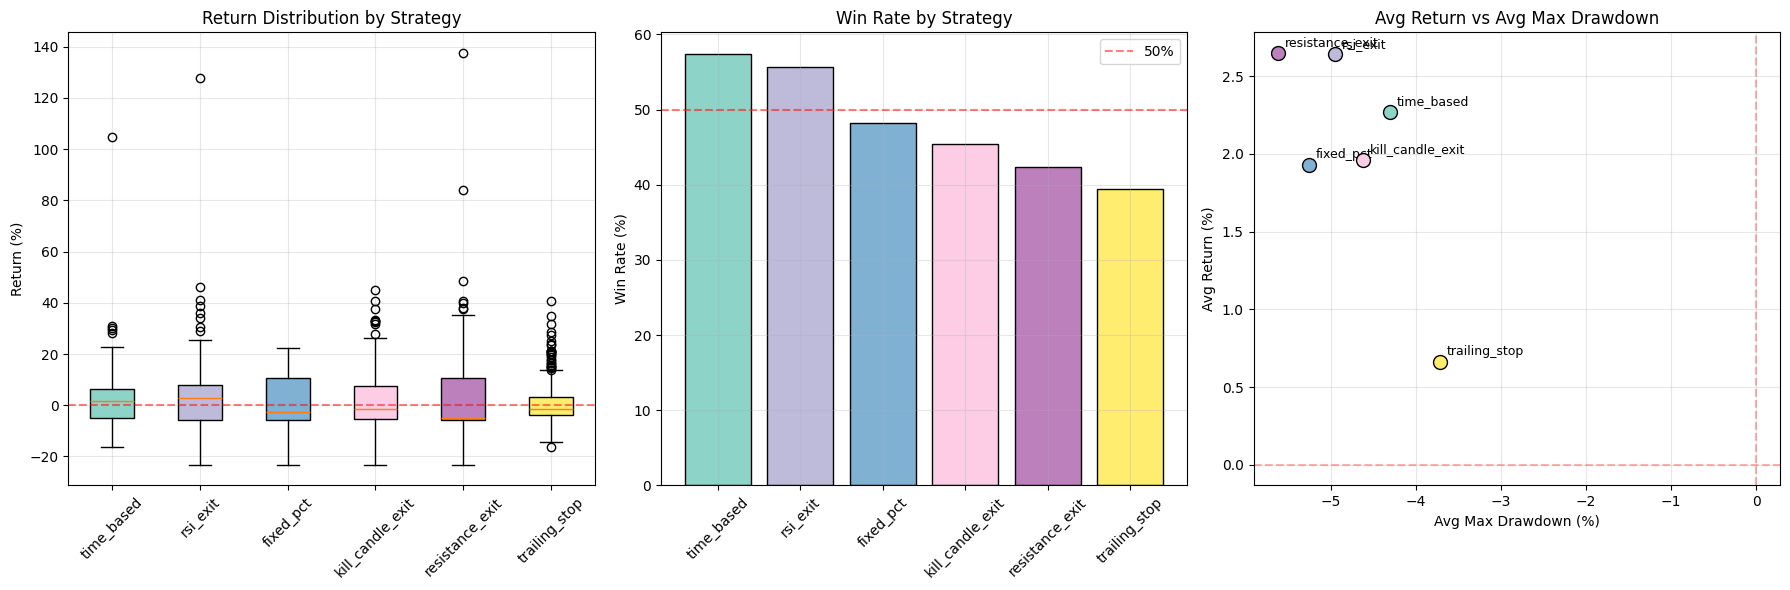

In [8]:
# Box plot: Return distribution by strategy
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Return distribution
ax1 = axes[0]
strategies = summary['strategy'].tolist()
data_for_box = [comparison[comparison['strategy'] == s]['return_pct'].values for s in strategies]
bp = ax1.boxplot(data_for_box, labels=strategies, patch_artist=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(strategies)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_title('Return Distribution by Strategy', fontsize=12)
ax1.set_ylabel('Return (%)')
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# 2. Win rate bar chart
ax2 = axes[1]
bars = ax2.bar(summary['strategy'], summary['win_rate'], color=colors, edgecolor='black')
ax2.set_title('Win Rate by Strategy', fontsize=12)
ax2.set_ylabel('Win Rate (%)')
ax2.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# 3. Avg return vs avg max drawdown scatter
ax3 = axes[2]
for i, row in summary.iterrows():
    ax3.scatter(row['avg_max_drawdown'], row['avg_return'], s=100, color=colors[i], edgecolor='black', zorder=5)
    ax3.annotate(row['strategy'], (row['avg_max_drawdown'], row['avg_return']),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)
ax3.set_title('Avg Return vs Avg Max Drawdown', fontsize=12)
ax3.set_xlabel('Avg Max Drawdown (%)')
ax3.set_ylabel('Avg Return (%)')
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.3)
ax3.axvline(x=0, color='red', linestyle='--', alpha=0.3)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Parameter Sensitivity

In [9]:
# Grid search: fixed_pct take-profit levels
tp_levels = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]
tp_results = []

print("Grid search: fixed_pct take-profit levels")
for tp in tp_levels:
    comp = bt.compare_strategies(
        stock_data, trades_input,
        strategies=['fixed_pct'],
        strategy_params={'fixed_pct': {'tp': tp}}
    )
    s = bt.summarize_comparison(comp)
    if not s.empty:
        row = s.iloc[0].to_dict()
        row['param_value'] = tp * 100
        tp_results.append(row)
    print(f"  tp={tp*100:.0f}%: avg_return={row['avg_return']:.2f}%, win_rate={row['win_rate']:.1f}%")

tp_grid = pd.DataFrame(tp_results)
display(tp_grid[['param_value', 'avg_return', 'win_rate', 'sharpe', 'profit_factor', 'avg_hold_days']])

Grid search: fixed_pct take-profit levels


  tp=5%: avg_return=1.50%, win_rate=63.0%


  tp=8%: avg_return=1.68%, win_rate=51.6%


  tp=10%: avg_return=1.93%, win_rate=48.2%


  tp=12%: avg_return=2.16%, win_rate=46.2%


  tp=15%: avg_return=2.41%, win_rate=44.6%


  tp=20%: avg_return=2.44%, win_rate=43.4%


,param_value,avg_return,win_rate,sharpe,profit_factor,avg_hold_days
0,5.0,1.50,63.0,0.242,1.65,15.1
1,8.0,1.68,51.6,0.212,1.56,21.8
2,10.0,1.93,48.2,0.221,1.61,25.1
3,12.0,2.16,46.2,0.230,1.66,27.9
4,15.0,2.41,44.6,0.236,1.71,31.3
5,20.0,2.44,43.4,0.224,1.71,35.4


In [10]:
# Grid search: trailing_stop trail levels
trail_levels = [0.03, 0.05, 0.07, 0.10]
trail_results = []

print("Grid search: trailing_stop trail levels")
for trail in trail_levels:
    comp = bt.compare_strategies(
        stock_data, trades_input,
        strategies=['trailing_stop'],
        strategy_params={'trailing_stop': {'trail': trail}}
    )
    s = bt.summarize_comparison(comp)
    if not s.empty:
        row = s.iloc[0].to_dict()
        row['param_value'] = trail * 100
        trail_results.append(row)
    print(f"  trail={trail*100:.0f}%: avg_return={row['avg_return']:.2f}%, win_rate={row['win_rate']:.1f}%")

trail_grid = pd.DataFrame(trail_results)
display(trail_grid[['param_value', 'avg_return', 'win_rate', 'sharpe', 'profit_factor', 'avg_hold_days']])

Grid search: trailing_stop trail levels
  trail=3%: avg_return=0.05%, win_rate=38.2%


  trail=5%: avg_return=0.66%, win_rate=39.4%


  trail=7%: avg_return=1.72%, win_rate=44.0%


  trail=10%: avg_return=2.27%, win_rate=44.4%


,param_value,avg_return,win_rate,sharpe,profit_factor,avg_hold_days
0,3.0,0.05,38.2,0.009,1.03,8.2
1,5.0,0.66,39.4,0.091,1.29,16.9
2,7.0,1.72,44.0,0.194,1.68,27.6
3,10.0,2.27,44.4,0.219,1.75,35.2


In [11]:
# Grid search: rsi_exit threshold levels
rsi_levels = [65, 70, 75, 80]
rsi_results = []

print("Grid search: rsi_exit threshold levels")
for rsi_th in rsi_levels:
    comp = bt.compare_strategies(
        stock_data, trades_input,
        strategies=['rsi_exit'],
        strategy_params={'rsi_exit': {'threshold': rsi_th}}
    )
    s = bt.summarize_comparison(comp)
    if not s.empty:
        row = s.iloc[0].to_dict()
        row['param_value'] = rsi_th
        rsi_results.append(row)
    print(f"  rsi_threshold={rsi_th}: avg_return={row['avg_return']:.2f}%, win_rate={row['win_rate']:.1f}%")

rsi_grid = pd.DataFrame(rsi_results)
display(rsi_grid[['param_value', 'avg_return', 'win_rate', 'sharpe', 'profit_factor', 'avg_hold_days']])

Grid search: rsi_exit threshold levels


  rsi_threshold=65: avg_return=2.45%, win_rate=59.0%


  rsi_threshold=70: avg_return=2.64%, win_rate=55.6%


  rsi_threshold=75: avg_return=2.73%, win_rate=51.4%


  rsi_threshold=80: avg_return=2.67%, win_rate=47.0%


,param_value,avg_return,win_rate,sharpe,profit_factor,avg_hold_days
0,65,2.45,59.0,0.241,1.99,21.0
1,70,2.64,55.6,0.242,1.96,23.0
2,75,2.73,51.4,0.230,1.90,25.9
3,80,2.67,47.0,0.220,1.81,29.3


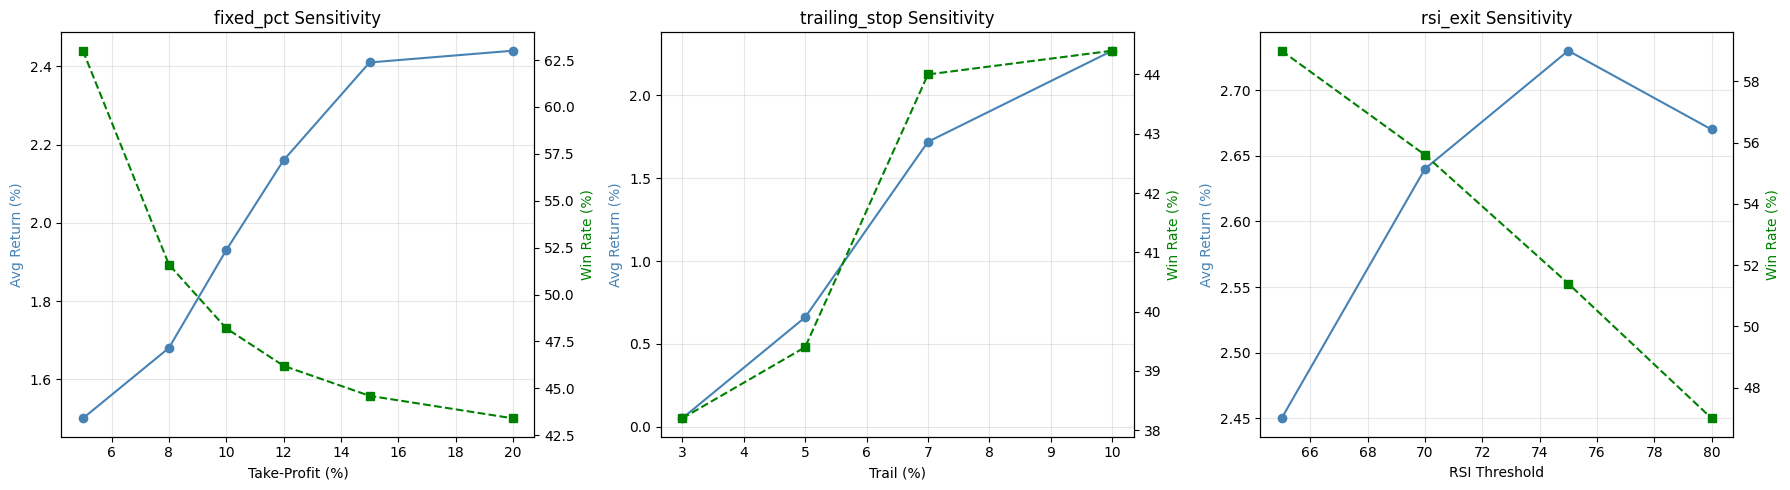

In [12]:
# Visualize parameter sensitivity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# fixed_pct
ax = axes[0]
ax.plot(tp_grid['param_value'], tp_grid['avg_return'], 'o-', color='steelblue', label='Avg Return')
ax2 = ax.twinx()
ax2.plot(tp_grid['param_value'], tp_grid['win_rate'], 's--', color='green', label='Win Rate')
ax.set_xlabel('Take-Profit (%)')
ax.set_ylabel('Avg Return (%)', color='steelblue')
ax2.set_ylabel('Win Rate (%)', color='green')
ax.set_title('fixed_pct Sensitivity')
ax.grid(True, alpha=0.3)

# trailing_stop
ax = axes[1]
ax.plot(trail_grid['param_value'], trail_grid['avg_return'], 'o-', color='steelblue', label='Avg Return')
ax2 = ax.twinx()
ax2.plot(trail_grid['param_value'], trail_grid['win_rate'], 's--', color='green', label='Win Rate')
ax.set_xlabel('Trail (%)')
ax.set_ylabel('Avg Return (%)', color='steelblue')
ax2.set_ylabel('Win Rate (%)', color='green')
ax.set_title('trailing_stop Sensitivity')
ax.grid(True, alpha=0.3)

# rsi_exit
ax = axes[2]
ax.plot(rsi_grid['param_value'], rsi_grid['avg_return'], 'o-', color='steelblue', label='Avg Return')
ax2 = ax.twinx()
ax2.plot(rsi_grid['param_value'], rsi_grid['win_rate'], 's--', color='green', label='Win Rate')
ax.set_xlabel('RSI Threshold')
ax.set_ylabel('Avg Return (%)', color='steelblue')
ax2.set_ylabel('Win Rate (%)', color='green')
ax.set_title('rsi_exit Sensitivity')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. HEIGHT_SCORE Analysis

Does a high HEIGHT_SCORE at entry predict lower optimal take-profit?

In [13]:
# Enrich trades with HEIGHT_SCORE at entry
height_scores = []

for _, trade in trades_input.iterrows():
    ticker = trade['ticker']

    if ticker not in stock_data:
        height_scores.append(np.nan)
        continue

    df = stock_data[ticker]
    entry_date = pd.Timestamp(trade['entry_date'])

    # Align entry_date timezone to match df.index (handles tz-naive and tz-aware indexes)
    idx_tz = df.index.tz if hasattr(df.index, 'tz') else None
    if idx_tz is not None:
        entry_date = entry_date.tz_localize(idx_tz) if entry_date.tzinfo is None else entry_date.tz_convert(idx_tz)
    elif entry_date.tzinfo is not None:
        entry_date = entry_date.tz_convert(None)

    mask = df.index <= entry_date
    if mask.any() and 'HEIGHT_SCORE' in df.columns:
        height_scores.append(df.loc[mask, 'HEIGHT_SCORE'].iloc[-1])
    else:
        height_scores.append(np.nan)

trades_input = trades_input.copy()
trades_input['HEIGHT_SCORE'] = height_scores

print(f"HEIGHT_SCORE stats at entry:")
print(trades_input['HEIGHT_SCORE'].describe())

HEIGHT_SCORE stats at entry:
count    500.000000
mean       0.000014
std        0.000223
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.003709
Name: HEIGHT_SCORE, dtype: float64


In [14]:
# Split trades into HIGH vs LOW height score groups
median_hs = trades_input['HEIGHT_SCORE'].median()
trades_high = trades_input[trades_input['HEIGHT_SCORE'] >= median_hs]
trades_low = trades_input[trades_input['HEIGHT_SCORE'] < median_hs]

print(f"Median HEIGHT_SCORE: {median_hs:.3f}")
print(f"HIGH group: {len(trades_high)} trades")
print(f"LOW group: {len(trades_low)} trades")

# Compare fixed_pct performance for both groups
results_by_group = {}

for group_name, group_trades in [('HIGH_HS', trades_high), ('LOW_HS', trades_low)]:
    if group_trades.empty:
        continue
    comp = bt.compare_strategies(stock_data, group_trades)
    summ = bt.summarize_comparison(comp)
    results_by_group[group_name] = summ
    print(f"\n{'='*60}")
    print(f"{group_name} GROUP (HEIGHT_SCORE {'>='+str(round(median_hs,3)) if group_name=='HIGH_HS' else '<'+str(round(median_hs,3))})")
    print(f"{'='*60}")
    display(summ)

Median HEIGHT_SCORE: 0.000
HIGH group: 500 trades
LOW group: 0 trades



HIGH_HS GROUP (HEIGHT_SCORE >=0.0)


,strategy,trades,avg_return,median_return,win_rate,avg_hold_days,sharpe,profit_factor,avg_max_gain,avg_max_drawdown
0,time_based,500,2.27,1.83,57.4,16.5,0.255,2.08,7.42,-4.31
1,rsi_exit,500,2.64,2.66,55.6,23.0,0.242,1.96,8.98,-4.95
2,fixed_pct,500,1.93,-2.66,48.2,25.1,0.221,1.61,7.81,-5.26
3,kill_candle_exit,500,1.96,-1.54,45.4,28.9,0.204,1.72,9.61,-4.62
4,resistance_exit,500,2.65,-5.12,42.4,39.2,0.198,1.75,11.80,-5.63
5,trailing_stop,500,0.66,-1.46,39.4,16.9,0.091,1.29,7.31,-3.72


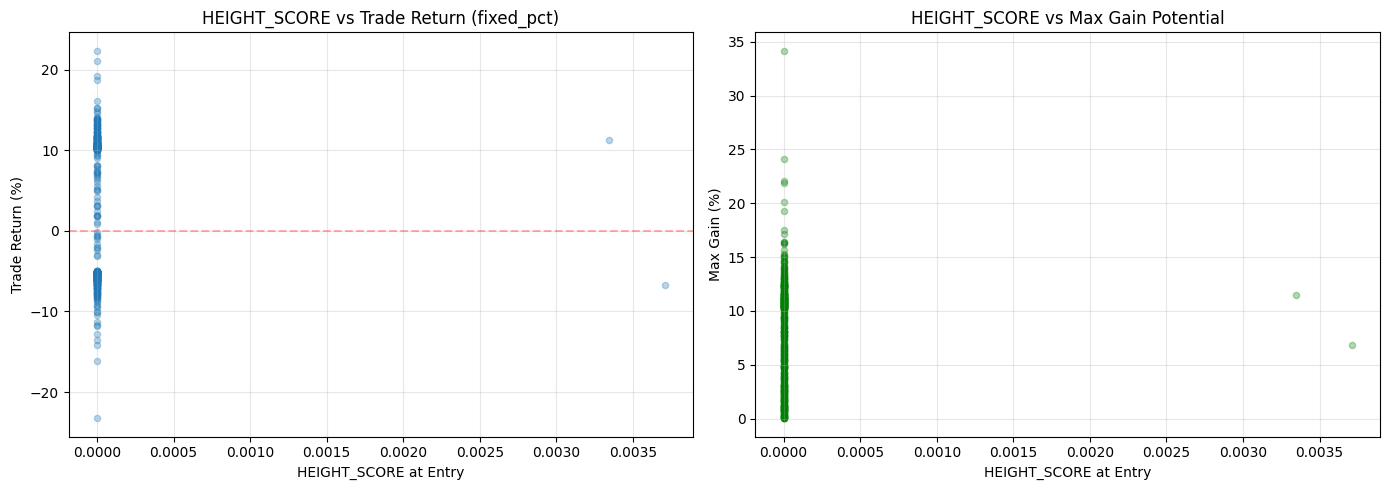


Correlation (HEIGHT_SCORE vs Return): -0.0009
Correlation (HEIGHT_SCORE vs Max Gain): 0.0165


In [15]:
# Scatter: HEIGHT_SCORE at entry vs max_gain achieved (fixed_pct results)
fixed_comp = comparison[comparison['strategy'] == 'fixed_pct'].copy()

# Merge HEIGHT_SCORE
hs_map = trades_input.set_index(['ticker', 'entry_date'])['HEIGHT_SCORE']
fixed_comp['entry_date_str'] = fixed_comp['entry_date'].astype(str)
trades_input_copy = trades_input.copy()
trades_input_copy['entry_date_str'] = trades_input_copy['entry_date'].astype(str)
hs_lookup = trades_input_copy.set_index(['ticker', 'entry_date_str'])['HEIGHT_SCORE']

fixed_comp['HEIGHT_SCORE'] = fixed_comp.apply(
    lambda row: hs_lookup.get((row['ticker'], row['entry_date_str']), np.nan), axis=1
)

valid = fixed_comp.dropna(subset=['HEIGHT_SCORE'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: HEIGHT_SCORE vs return
ax = axes[0]
ax.scatter(valid['HEIGHT_SCORE'], valid['return_pct'], alpha=0.3, s=20)
ax.set_xlabel('HEIGHT_SCORE at Entry')
ax.set_ylabel('Trade Return (%)')
ax.set_title('HEIGHT_SCORE vs Trade Return (fixed_pct)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)

# Scatter: HEIGHT_SCORE vs max_gain
ax = axes[1]
ax.scatter(valid['HEIGHT_SCORE'], valid['max_gain_pct'], alpha=0.3, s=20, color='green')
ax.set_xlabel('HEIGHT_SCORE at Entry')
ax.set_ylabel('Max Gain (%)')
ax.set_title('HEIGHT_SCORE vs Max Gain Potential')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation
if len(valid) > 10:
    corr_return = valid['HEIGHT_SCORE'].corr(valid['return_pct'])
    corr_gain = valid['HEIGHT_SCORE'].corr(valid['max_gain_pct'])
    print(f"\nCorrelation (HEIGHT_SCORE vs Return): {corr_return:.4f}")
    print(f"Correlation (HEIGHT_SCORE vs Max Gain): {corr_gain:.4f}")

## Summary

This notebook provides:

1. **Strategy Comparison**: Side-by-side comparison of 6 exit strategies
2. **Visualization**: Box plots, bar charts, and scatter plots
3. **Parameter Sensitivity**: Grid search for fixed_pct, trailing_stop, rsi_exit
4. **HEIGHT_SCORE Analysis**: Impact of overbought conditions on exit strategy performance

### Key Metrics

| Metric | Description |
|--------|-------------|
| avg_return | Mean return across all trades |
| win_rate | Percentage of trades with positive return |
| sharpe | Risk-adjusted return (avg_return / std_return) |
| profit_factor | Gross profit / gross loss |
| avg_hold_days | Average holding period |